In [13]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
matchup_data = pd.read_csv("matchup_features.csv")

matchup_data.head()

,gameId,season_year,home_win,home_team,home_last_5_win_pct,home_offensive_average,home_defensive_average,home_last_5_point_diff,away_season_year,away_home_win,away_team,away_last_5_win_pct,away_offensive_average,away_defensive_average,away_last_5_point_diff,win_pct_diff,offense_diff,defense_diff,point_diff_diff
0,22000083,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,2021,0,Cleveland Cavaliers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22000095,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,2021,0,New York Knicks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22000110,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,2021,0,Charlotte Hornets,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22000153,2021,1,Atlanta Hawks,0.2,102.4,104.0,-1.6,2021,1,Philadelphia 76ers,0.6,119.6,117.2,2.4,-0.4,-17.2,-13.2,-4.0
4,22000205,2021,1,Atlanta Hawks,0.2,101.8,107.4,-5.6,2021,1,Minnesota Timberwolves,0.2,111.6,117.8,-6.2,0.0,-9.8,-10.4,0.6


In [23]:
feature_cols = [
    "win_pct_diff",
    "offense_diff",
    "defense_diff",
    "point_diff_diff"
]

model_df = matchup_data[
    feature_cols + ["home_win", "season_year"]
].dropna()
model_df.head()

,win_pct_diff,offense_diff,defense_diff,point_diff_diff,home_win,season_year
3,-0.4,-17.2,-13.2,-4.0,1,2021
4,0.0,-9.8,-10.4,0.6,1,2021
5,0.0,-0.2,1.6,-1.8,1,2021
6,-0.4,-8.4,10.6,-19.0,1,2021
7,0.2,-5.8,-13.2,7.4,0,2021


creating X and Y

In [25]:
X = matchup_data[feature_cols]

y = matchup_data["home_win"] # our target variable

In [26]:
train_df = model_df[model_df["season_year"] <= 2024].copy()
test_df = model_df[model_df["season_year"] == 2025].copy()

X_train = train_df[feature_cols]
y_train = train_df["home_win"]

X_test = test_df[feature_cols]
y_test = test_df["home_win"]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5736, 4)
Testing shape: (1387, 4)


5736 rows and 4 columns. in training data from 2021-2024. 1387 rows and 4 columns in test data from 2024-2025.

Now we will be trying different models.

Logistic regression

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

preds = log_model.predict(X_test)

probs = log_model.predict_proba(X_test)[:, 1]

In [28]:
accuracy = accuracy_score(y_test, preds)

print("Accuracy:", accuracy)

print("Classification Report:")
print(classification_report(y_test, preds))

Accuracy: 0.6337418889689979
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.45      0.53       630
           1       0.63      0.79      0.70       757

    accuracy                           0.63      1387
   macro avg       0.63      0.62      0.61      1387
weighted avg       0.63      0.63      0.62      1387



model correctly predicted 63.5% of the outcomes in the test set.so 878 games are good.  When the model predicts an away team win it is correct 64% of time and 63% of home wins.  This model captures only 0.45 the wins by an away team. so the model favors the home team predictions. so the home team with strong recent forms usually win. 

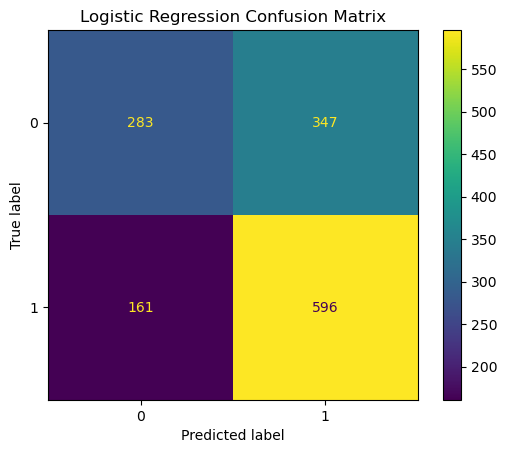

In [29]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

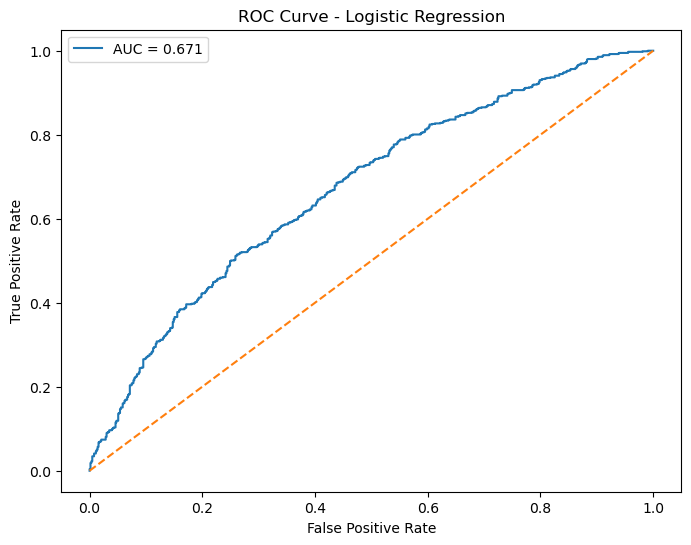

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, probs)

auc_score = roc_auc_score(y_test, probs)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

Orange dashed line is random guessing and the blue lineis my model. AUC= 0.671 means meaningful predictive skills.

Feature Importance

In [32]:
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
0,win_pct_diff,0.081652
3,point_diff_diff,0.025844
1,offense_diff,0.013964
2,defense_diff,-0.011879


so momentum or the last 5 win pct for the home team is greater than for the away, they usally win.

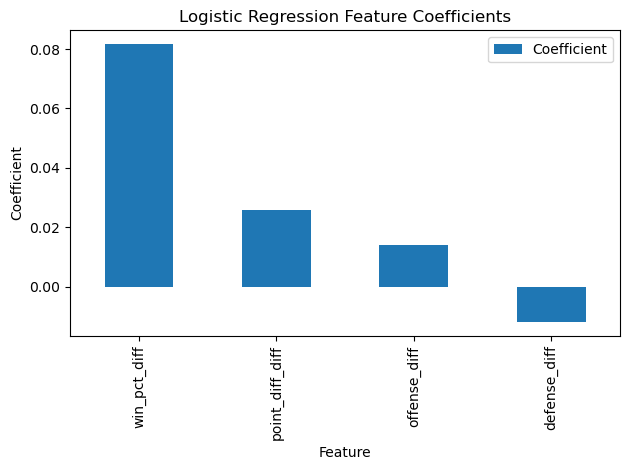

In [33]:
coef_df.plot(
    x="Feature",
    y="Coefficient",
    kind="bar"
)

plt.title("Logistic Regression Feature Coefficients")

plt.ylabel("Coefficient")

plt.tight_layout()

plt.show()

Ridge model

In [34]:
ridge_model = LogisticRegression(
    penalty="l2",
    C=1.0, # controls regularization strength
    max_iter=1000
)

ridge_model.fit(X_train, y_train)

c:\Users\Dell\miniforge3\envs\math4025\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [35]:
ridge_preds = ridge_model.predict(X_test)

ridge_probs = ridge_model.predict_proba(X_test)[:, 1]

ridge_accuracy = accuracy_score(
    y_test,
    ridge_preds
)

ridge_auc = roc_auc_score(
    y_test,
    ridge_probs
)

print("Ridge Accuracy:", ridge_accuracy)
print("Ridge ROC-AUC:", ridge_auc)


Ridge Accuracy: 0.6337418889689979
Ridge ROC-AUC: 0.6712975194481139


In [36]:
ridge_coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": ridge_model.coef_[0]
})

ridge_coef_df = ridge_coef_df.sort_values(
    "Coefficient",
    ascending=False
)

ridge_coef_df

,Feature,Coefficient
0,win_pct_diff,0.081652
3,point_diff_diff,0.025844
1,offense_diff,0.013964
2,defense_diff,-0.011879


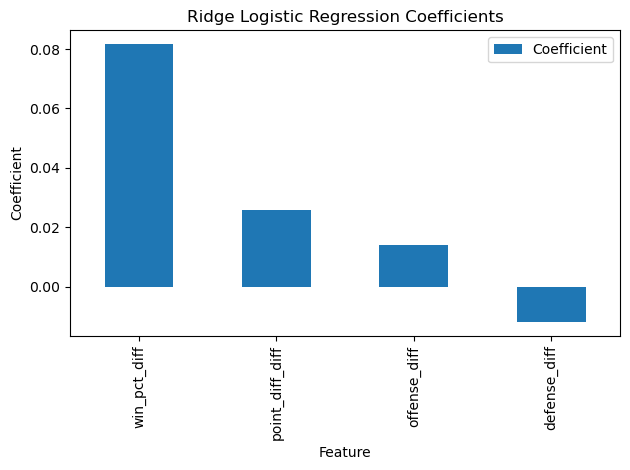

In [38]:
ridge_coef_df.plot(
    x="Feature",
    y="Coefficient",
    kind="bar"
)

plt.title("Ridge Logistic Regression Coefficients")

plt.ylabel("Coefficient")

plt.tight_layout()

plt.show()

good feature engineering. less overfitting.  but not much improvement in accuracy.